# 🩺 Chest X-Ray Classification Project

**Objective:**  
Build a CNN to classify chest X-ray images as **NORMAL** or **PNEUMONIA**.

**Dataset:**  
Kaggle Chest X-Ray dataset

**Dataset Structure:**

data/chest_xray/
    train/
        NORMAL/
        PNEUMONIA/
    val/
        NORMAL/
        PNEUMONIA/
    test/
        NORMAL/
        PNEUMONIA/


**Notes:**  
- Only the `chest_xray` folder will be used; `__MACOSX` can be ignored.  
- Data augmentation will be applied to the training set to prevent overfitting.  
- Validation and Test sets will only be resized and normalized.

# 1️⃣ Imports & Device Setup

**Objective:**  
- Import all necessary libraries  
- Check if GPU is available  
- Set device for PyTorch (CPU/GPU)

> Using GPU drastically speeds up model training. If CUDA is not available, CPU will be used.

In [2]:
# 1️⃣ Imports
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# 2️⃣ Data Transforms & Augmentation

**Objective:**  
- Prepare images for training & validation/test  
- Apply **augmentation** only to training data to prevent overfitting

**Transformations:**
- `Resize((224,224))` → Uniform input size for CNN
- `RandomHorizontalFlip()` → Random flips for augmentation (training only)
- `ToTensor()` → Convert image to PyTorch tensor
- `Normalize([0.5], [0.5])` → Normalize pixel values to [-1,1]

> Validation/Test: Only resize + normalize, no augmentation

In [3]:
# 2️⃣ Data Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 3️⃣ Dataset Loading

**Objective:**  
- Load the dataset using `ImageFolder`  
- Automatically assign labels based on folder names:  
  - `NORMAL → 0`  
  - `PNEUMONIA → 1`  
- Use transformations defined earlier

In [4]:
# ===============================
# Step 4️⃣: Dataset Loading
# ===============================
from torchvision import datasets
import os

# Base dataset folder (relative to notebook folder)
data_dir = "../data"  # one level up from notebooks folder

# Dataset loading using ImageFolder
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(root=os.path.join(data_dir, "val"), transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=os.path.join(data_dir, "test"), transform=val_test_transform)

# Print number of images in each set
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of test images: {len(test_dataset)}")

Number of training images: 5216
Number of validation images: 16
Number of test images: 624


# 4️⃣ DataLoader

**Objective:**  
- Create batches for training, validation, and test sets  
- Shuffle training data for better generalization  
- Maintain order in validation/test sets for consistent evaluation

In [5]:
# 4️⃣ DataLoader
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Verify one batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # [batch_size, channels, height, width]
print(f"Labels: {labels}")

Batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        0, 1, 1, 1, 1, 1, 1, 1])


# 5️⃣ Sample Batch Visualization

**Objective:**  
- Verify images are loaded correctly  
- Check transformations (resize, normalization, augmentation)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6021352].


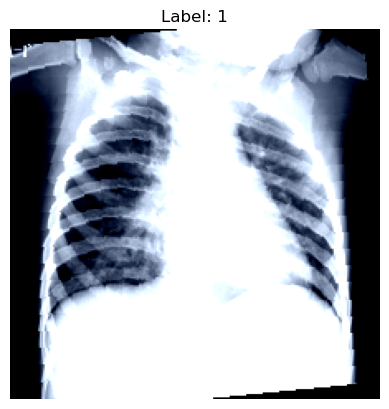

In [6]:
# 5️⃣ Visualize first image in the batch
img = images[0].numpy().transpose((1, 2, 0))  # C,H,W → H,W,C
img = (img * 0.5) + 0.5                        # Denormalize to [0,1]

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.axis('off')
plt.show()

# 🟢 Step 6: Model Definition (ResNet18 / CNN)

## **Objective:**  
- Use pretrained **ResNet18** model (trained on ImageNet)  
- Modify last layer for **2-class output**: NORMAL vs PNEUMONIA  
- Move model to **GPU / CPU** for training  


In [16]:
# ===============================
# Step 6️⃣: Model Definition
# ===============================
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze all layers (optional: if you want only last layer to train)
model = models.resnet18(weights="IMAGENET1K_V1")

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)
# Move model to device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Loss Function & Optimizer Setup

## **Objective:**  
- **Define the loss function** → to compare the model’s output with the actual labels  
- **Define the optimizer** → to update the model’s parameters during training  
- **Prepare for the training loop**  

---

## **Key Points:**
1. `CrossEntropyLoss` → used when the output is logits and labels are in integer form  
2. `Adam` optimizer → adapts the learning rate automatically for faster convergence  
3. Learning rate scheduler (optional) → helps make training more stable  
4. This setup is now **ready for the training loop**

In [17]:
# ===============================
# Step 7️⃣: Loss Function & Optimizer
# ===============================
import torch.optim as optim
import torch.nn as nn

# Loss function → CrossEntropy for multi-class / 2-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer → Adam optimizer (fast convergence)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.0001)

# Learning rate scheduler (optional, improves training)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Print confirmation
print("Loss function, optimizer, and scheduler ready ✅")

Loss function, optimizer, and scheduler ready ✅


# Training & Validation Loop

## **Objective:**  
- Train the model on **training data**  
- Validate on **validation data** each epoch  
- Track **loss and accuracy** for both training and validation  
- Ready for **evaluation on test data**

---

## **Key Points:**
1. **Forward pass:** model predictions on input batch  
2. **Compute loss:** compare predictions with true labels  
3. **Backward pass:** gradients calculation  
4. **Optimizer step:** update model parameters  
5. **Validation:** check model performance without updating weights  
6. Track metrics → helps decide when model is learning well

In [18]:
# ===============================
# Step 8️⃣: Training + Validation Loop
# ===============================
import torch
import time

num_epochs = 10  # can increase later

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # ---------- Training ----------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # ---------- Validation ----------
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_correct / val_total
    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

Epoch [1/10] Train Loss: 0.5794, Train Acc: 0.7122 Val Loss: 0.7811, Val Acc: 0.5000
Epoch [2/10] Train Loss: 0.4086, Train Acc: 0.8098 Val Loss: 0.5709, Val Acc: 0.6250
Epoch [3/10] Train Loss: 0.3315, Train Acc: 0.8669 Val Loss: 0.4484, Val Acc: 0.7500
Epoch [4/10] Train Loss: 0.2909, Train Acc: 0.8865 Val Loss: 0.4079, Val Acc: 0.8125
Epoch [5/10] Train Loss: 0.2668, Train Acc: 0.8967 Val Loss: 0.3933, Val Acc: 0.8125
Epoch [6/10] Train Loss: 0.2478, Train Acc: 0.9028 Val Loss: 0.3587, Val Acc: 0.8125
Epoch [7/10] Train Loss: 0.2399, Train Acc: 0.9072 Val Loss: 0.3634, Val Acc: 0.8125
Epoch [8/10] Train Loss: 0.2198, Train Acc: 0.9162 Val Loss: 0.4068, Val Acc: 0.7500
Epoch [9/10] Train Loss: 0.2098, Train Acc: 0.9225 Val Loss: 0.3382, Val Acc: 0.8750
Epoch [10/10] Train Loss: 0.2084, Train Acc: 0.9210 Val Loss: 0.3415, Val Acc: 0.8125


# 💾 Model Saving

**Objective:**  
Save the trained model weights for future inference or deployment. This allows you to reload the model later without retraining.

**Details:**  
- Using `torch.save()` to save the `state_dict` of the model.  
- The file is saved in the `models` directory as `model.pth`.  
- Only the model parameters are saved, not the entire architecture, which is memory-efficient and standard practice.

In [19]:
import torch

# Save model weights
torch.save(model.state_dict(), "../models/model.pth")
print("Model saved successfully!")

Model saved successfully!


**Objective:**  
Check the number of images in each class (`NORMAL` = 0, `PNEUMONIA` = 1) for both training and test sets. This helps identify class imbalance, which can affect model performance.

In [21]:
from collections import Counter

print("Train:", Counter(train_dataset.targets))
print("Test:", Counter(test_dataset.targets))

Train: Counter({1: 3875, 0: 1341})
Test: Counter({1: 390, 0: 234})


# Model Loading & Inference Preparation

**Objective:**  
Load the previously trained model weights to perform evaluation or inference without retraining. This ensures that the model can be reused efficiently.

**Details:**  
- Use the **same architecture** as during training (`ResNet18`).  
- Load the saved `state_dict` from disk.  
- Move the model to the correct device (`CPU` or `GPU`) and set it to evaluation mode.  
- `eval()` disables dropout and batch normalization updates, ensuring consistent 

In [22]:
from torchvision import models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SAME architecture as training
model = models.resnet18(weights=None)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# Load state_dict
model_path = r"E:\Projects\chest-xray-pneumonia-detection\models\model.pth"

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

model.to(device)
model.eval()

print("Model Loaded Successfully ✅")

Model Loaded Successfully ✅


C:\Users\kalim\AppData\Local\Temp\ipykernel_5192\1326636674.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


# 🧪 Set Model to Evaluation Mode

**Objective:**  
Prepare the trained model for evaluation on validation or test data.


In [23]:
model.eval()
print("Model is in evaluation mode ✅")

Model is in evaluation mode ✅


In [ ]:
from torchvision import transforms

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
    
])

# Test Data Transformations

**Objective:**  
Prepare the test dataset with proper transformations so that it matches the input format expected by the trained model.


In [25]:
from torchvision import datasets
from torch.utils.data import DataLoader

test_path = r"E:\Projects\chest-xray-pneumonia-detection\data\test"

test_dataset = datasets.ImageFolder(test_path, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", test_dataset.classes)

Classes: ['NORMAL', 'PNEUMONIA']


# Model Evaluation / Testing

**Objective:**  
- Use the trained model to predict on unseen **test dataset**  
- Measure **accuracy**, **loss**, or other metrics  
- Check how well model generalizes beyond training/validation data

In [26]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 89.74%


**Objective:**  
Evaluate the trained model on the test dataset and visualize how well it classifies NORMAL vs PNEUMONIA images.

In [27]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[186  48]
 [ 16 374]]
